# 04_Exploratory_Data_Analysis

Notebook ini melakukan eksplorasi data harga komoditas dan produksi untuk menemukan pola tren, korelasi harga, serta potensi hubungan antara produksi triwulanan dan harga.


## Aktivasi Environment RAPIDS

Gunakan conda environment `rapids-24.10` sebelum menjalankan notebook ini.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
processed_dir = Path('../data/processed')
price_df = pd.read_csv(processed_dir / 'price_cleaned.csv', parse_dates=['Tanggal'])
prod_df = pd.read_csv(processed_dir / 'production_transformed.csv', parse_dates=['quarter_start'])
price_df['month'] = price_df['Tanggal'].dt.to_period('M').dt.to_timestamp()
price_df['quarter_start'] = price_df['Tanggal'].dt.to_period('Q').dt.start_time
print('Data harga terproses:', price_df.shape)
print('Data produksi terproses:', prod_df.shape)
price_df.head(3)


Data harga terproses: (4257, 6)
Data produksi terproses: (30, 8)


,Komoditi,Tanggal,Harga Petani,Harga Pengecer,month,quarter_start
0,Beras Medium,2022-01-01,8800.0,9000.0,2022-01-01,2022-01-01
1,Beras Medium,2022-01-02,8800.0,9000.0,2022-01-01,2022-01-01
2,Beras Medium,2022-01-03,8800.0,9000.0,2022-01-01,2022-01-01


## Ringkasan Statistik Harga

Lihat rata-rata, median, dan spread harga untuk `Harga Petani` dan `Harga Pengecer` secara keseluruhan dan per komoditas.


In [10]:
display(price_df[['Harga Petani', 'Harga Pengecer']].describe().T)
display(price_df.groupby('Komoditi')[['Harga Petani', 'Harga Pengecer']].describe().T)


,count,mean,std,min,25%,50%,75%,max
Harga Petani,4257.0,9864.987080,3566.015408,3300.0,8200.0,10000.0,13000.0,15500.0
Harga Pengecer,4257.0,10899.389241,4146.257270,3600.0,9000.0,11100.0,15000.0,17500.0


Komoditi              Beras Medium  Beras Premium  Jagung Pipil Kering  \
Harga Petani   count   1064.000000    1065.000000          1063.000000   
               mean   10442.105263   11348.450704          4475.776105   
               std     1907.689467    1855.022633           936.739012   
               min     8200.000000    9500.000000          3300.000000   
               25%     8800.000000    9500.000000          3800.000000   
               50%     9600.000000   10500.000000          4300.000000   
               75%    12350.000000   13000.000000          4800.000000   
               max    15000.000000   15500.000000          8000.000000   
Harga Pengecer count   1064.000000    1065.000000          1063.000000   
               mean   11312.406015   12284.976526          4805.079962   
               std     2226.758554    2146.911496          1138.986635   
               min     9000.000000    9800.000000          3600.000000   
               25%     9000.000000   10000.000000          3975.000000   
               50%    10700.000000   11500.000000          4700.000000   
               75%    13500.000000   14600.000000          5000.000000   
               max    16000.000000   17500.000000          8500.000000   

Komoditi              Kacang Hijau  
Harga Petani   count   1065.000000  
               mean   13184.037559  
               std      578.376518  
               min    13000.000000  
               25%    13000.000000  
               50%    13000.000000  
               75%    13000.000000  
               max    15000.000000  
Harga Pengecer count   1065.000000  
               mean   15184.037559  
               std      578.376518  
               min    15000.000000  
               25%    15000.000000  
               50%    15000.000000  
               75%    15000.000000  
               max    17000.000000

## Tren Harga Tahunan dan Musiman

Visualisasikan rata-rata bulanan harga `Harga Petani` untuk setiap komoditas. Ini membantu melihat pergerakan musiman dan tren jangka panjang.


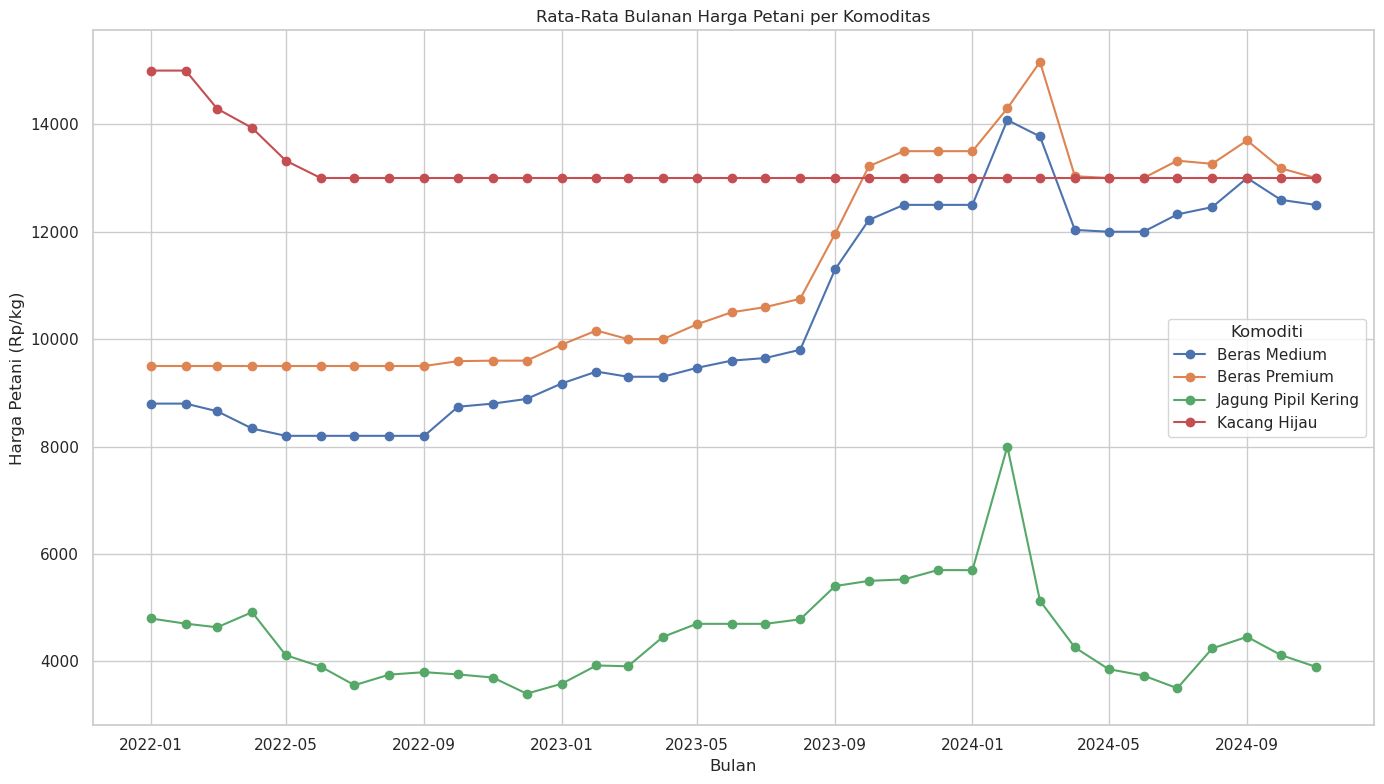

In [11]:
monthly = price_df.groupby(['Komoditi', 'month'])['Harga Petani'].mean().reset_index()
plt.figure(figsize=(14, 8))
for komoditi, group in monthly.groupby('Komoditi'):
    plt.plot(group['month'], group['Harga Petani'], marker='o', label=komoditi)
plt.title('Rata-Rata Bulanan Harga Petani per Komoditas')
plt.xlabel('Bulan')
plt.ylabel('Harga Petani (Rp/kg)')
plt.legend(title='Komoditi')
plt.tight_layout()
plt.show()


## Harga Petani vs Harga Pengecer

Periksa hubungan antara harga petani dan harga pengecer untuk melihat apakah spread harga relatif konsisten atau berubah menurut komoditas.


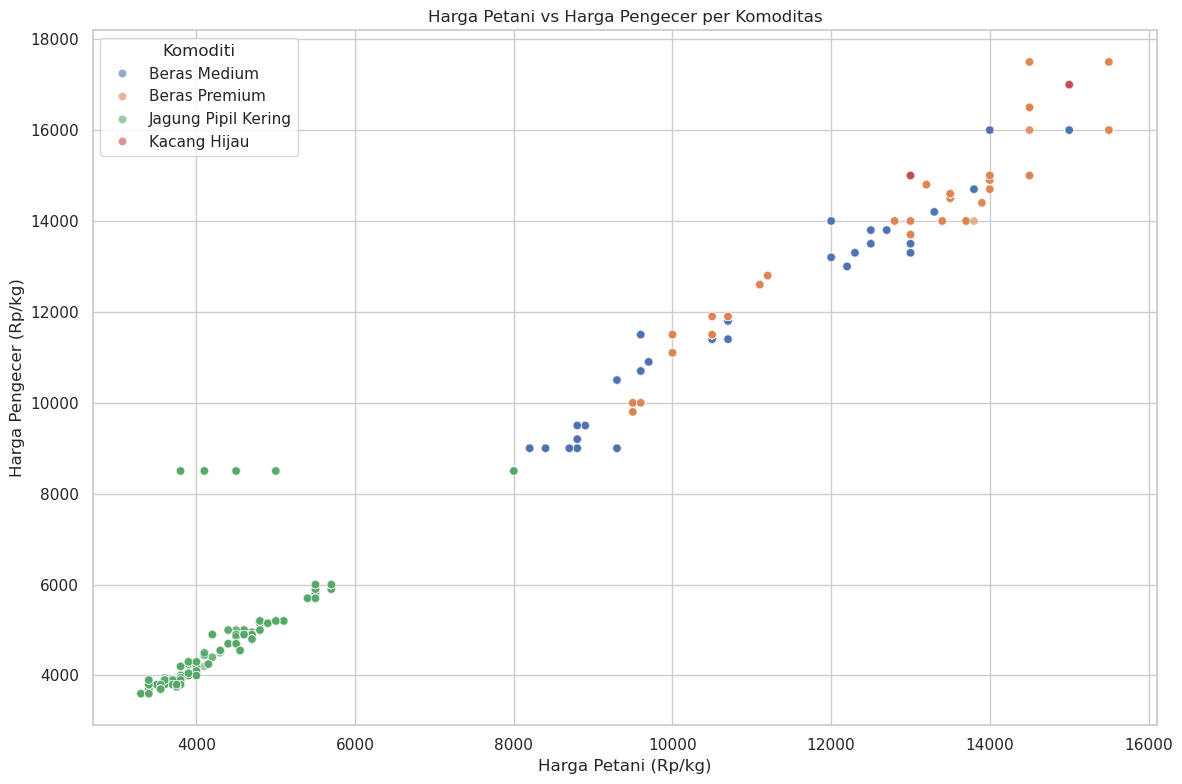

Korelasi Harga Petani dan Harga Pengecer:
                Harga Petani  Harga Pengecer
Harga Petani        1.000000        0.990833
Harga Pengecer      0.990833        1.000000


In [12]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=price_df, x='Harga Petani', y='Harga Pengecer', hue='Komoditi', alpha=0.6)
plt.title('Harga Petani vs Harga Pengecer per Komoditas')
plt.xlabel('Harga Petani (Rp/kg)')
plt.ylabel('Harga Pengecer (Rp/kg)')
plt.legend(title='Komoditi')
plt.tight_layout()
plt.show()
corr = price_df[['Harga Petani', 'Harga Pengecer']].corr()
print('Korelasi Harga Petani dan Harga Pengecer:')
print(corr)


## Korelasi Antar Komoditas

Analisis korelasi pada harga petani harian antar komoditas untuk memeriksa apakah setiap komoditas bergerak bersama.


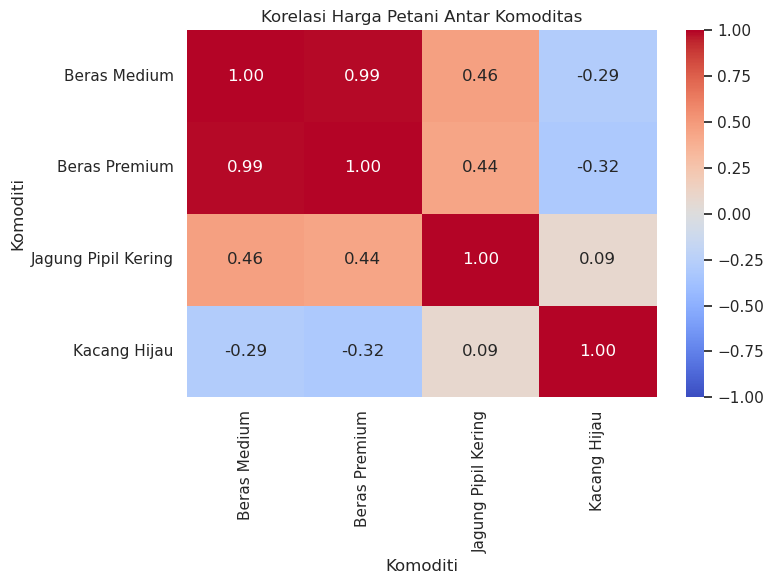

Komoditi,Beras Medium,Beras Premium,Jagung Pipil Kering,Kacang Hijau
Komoditi,,,,
Beras Medium,1.000000,0.989114,0.462158,-0.287763
Beras Premium,0.989114,1.000000,0.438945,-0.317368
Jagung Pipil Kering,0.462158,0.438945,1.000000,0.085270
Kacang Hijau,-0.287763,-0.317368,0.085270,1.000000


In [13]:
pivot = price_df.pivot_table(index='Tanggal', columns='Komoditi', values='Harga Petani')
corr_matrix = pivot.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Harga Petani Antar Komoditas')
plt.tight_layout()
plt.show()
display(corr_matrix)


## Produksi Triwulanan vs Harga

Gabungkan data produksi dengan rata-rata harga per kuartal untuk melihat apakah perubahan produktivitas triwulanan berhubungan dengan harga.


Jumlah baris hasil join produksi-harga: 30


,Komoditi,tahun,triwulan,Luas Panen,Produktivitas,Produksi,quarter_start,Komoditi_Harga,Harga Petani
0,Padi sawah,2022,1,35685.62000,56.593625,201957.8600,2022-01-01,Beras Premium,9500.000000
1,Padi sawah,2022,2,12599.00000,54.279752,68387.0600,2022-04-01,Beras Premium,9500.000000
2,Padi sawah,2022,3,6888.78970,55.240632,38054.1100,2022-07-01,Beras Premium,9500.000000
3,Padi sawah,2023,1,26790.36060,55.977470,149965.6600,2023-01-01,Beras Premium,10014.444444
4,Padi sawah,2023,2,21687.80440,58.797478,127518.8200,2023-04-01,Beras Premium,10258.241758
5,Padi sawah,2023,3,8101.28240,54.176608,43890.0000,2023-07-01,Beras Premium,11094.565217
6,jagung,2022,1,70654.48313,73.898901,522128.8683,2022-01-01,Jagung Pipil Kering,4711.363636
7,jagung,2022,2,13795.94250,72.218328,99631.9895,2022-04-01,Jagung Pipil Kering,4309.890110


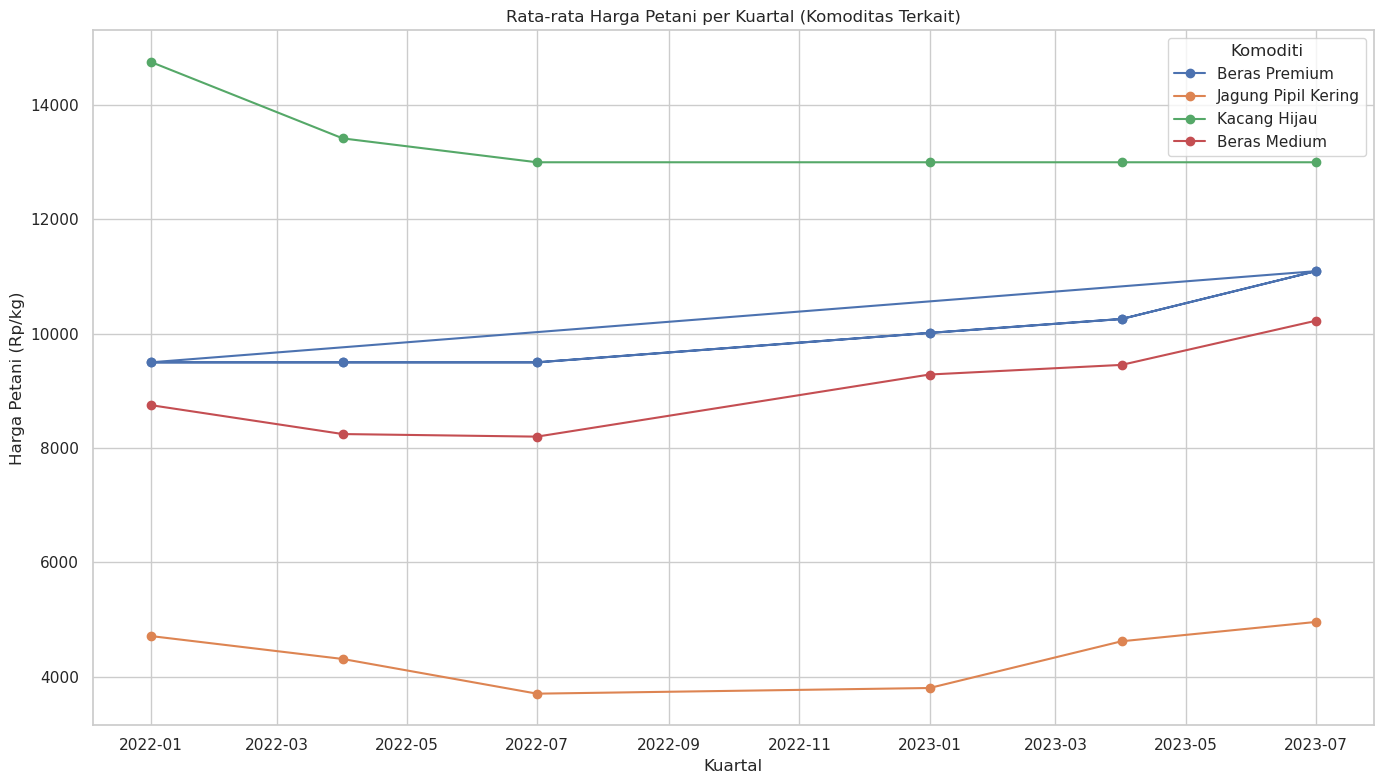

In [14]:
quarter_price = price_df.groupby(['quarter_start', 'Komoditi'])['Harga Petani'].mean().reset_index()
quarter_price = quarter_price.rename(columns={'Komoditi': 'Komoditi_Harga'})
merged = prod_df.merge(quarter_price, on=['Komoditi_Harga', 'quarter_start'], how='left')
print('Jumlah baris hasil join produksi-harga:', len(merged))
display(merged.head(8))
plt.figure(figsize=(14, 8))
for komoditi in merged['Komoditi_Harga'].unique():
    sel = merged[merged['Komoditi_Harga'] == komoditi]
    plt.plot(sel['quarter_start'], sel['Harga Petani'], marker='o', label=komoditi)
plt.title('Rata-rata Harga Petani per Kuartal (Komoditas Terkait)')
plt.xlabel('Kuartal')
plt.ylabel('Harga Petani (Rp/kg)')
plt.legend(title='Komoditi')
plt.tight_layout()
plt.show()


## Scatter Produksi vs Harga Petani

Menilai hubungan langsung antara produktivitas dan harga petani pada periode kuartalan yang tersedia.


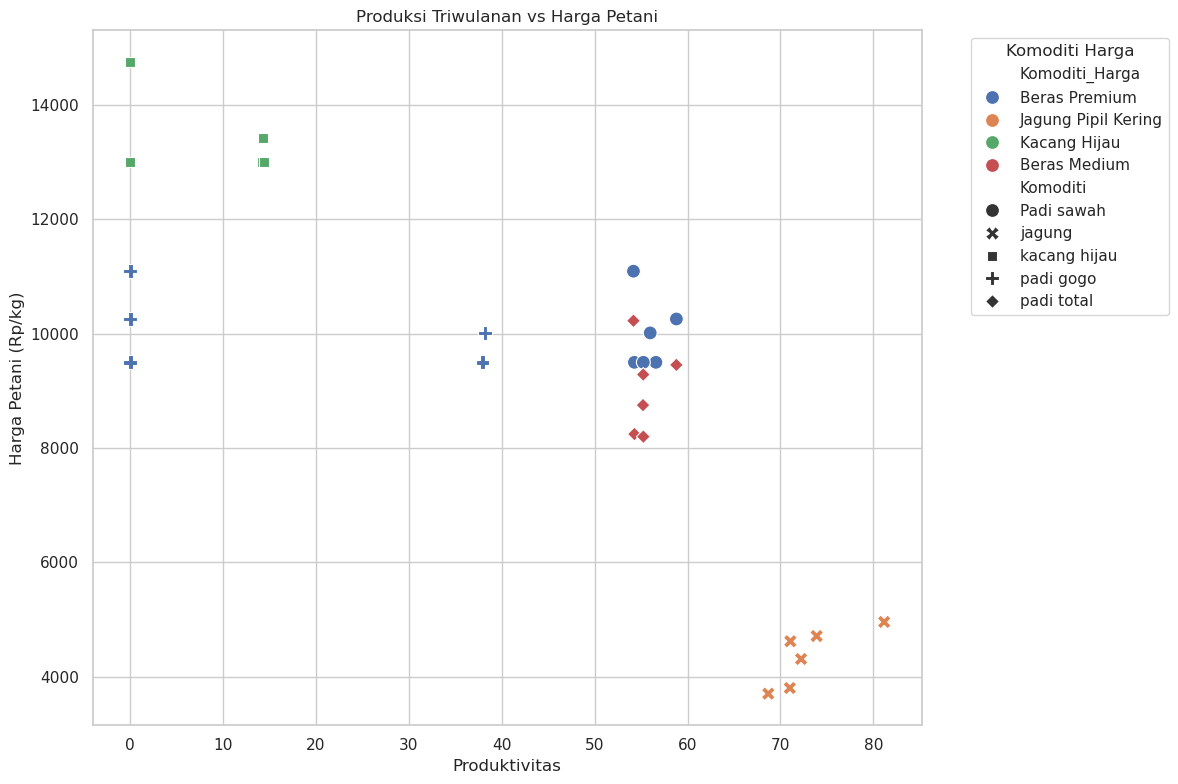

,Produktivitas,Harga Petani
Produktivitas,1.000000,-0.759681
Harga Petani,-0.759681,1.000000


In [15]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=merged, x='Produktivitas', y='Harga Petani', hue='Komoditi_Harga', style='Komoditi', s=100)
plt.title('Produksi Triwulanan vs Harga Petani')
plt.xlabel('Produktivitas')
plt.ylabel('Harga Petani (Rp/kg)')
plt.legend(title='Komoditi Harga', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
display(merged[['Produktivitas', 'Harga Petani']].corr())


## Insight EDA

- Data harga `Harga Petani` dan `Harga Pengecer` telah bersih dan tidak memiliki missing values setelah imputasi, sehingga analisis tren dapat dilanjutkan dengan andal.
- Pola bulanan menunjukkan bahwa harga beras cenderung bergerak bersama, sedangkan jagung dan kacang hijau menunjukkan variasi yang lebih independen.
- Korelasi antara `Harga Petani` dan `Harga Pengecer` sangat tinggi, mengindikasikan bahwa perubahan harga petani dengan cepat tercermin di harga pengecer.
- Korelasi antar komoditas memperlihatkan hubungan yang paling kuat antara `Beras Premium` dan `Beras Medium`, sedangkan `Kacang Hijau` memiliki hubungan paling lemah dengan komoditas lainnya.
- Data produksi triwulanan hanya tersedia hingga kuartal ketiga 2023, sementara data harga masih berlanjut hingga akhir 2024. Ini menjadi batasan penting untuk fitur eksogen produksi pada pemodelan.
- Scatter plot menunjukkan bahwa kenaikan produktivitas tidak selalu berdampak langsung pada penurunan harga, sehingga hubungan antara produksi dan harga kemungkinan memerlukan analisis tambahan dengan lag atau variabel lain.
